# Portfolio Optimization Using Modern Portfolio Theory

This notebook implements portfolio optimization using historical stock returns.

Objectives:

- Generate random portfolios
- Calculate expected return and risk
- Compute Sharpe ratios
- Visualize the risk-return tradeoff
- Identify the optimal portfolio

Modern Portfolio Theory (MPT), introduced by Harry Markowitz, suggests that investors can construct portfolios that maximize expected return for a given level of risk through diversification.

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')

In [2]:
data = pd.read_csv(
    '../data/stock_prices.csv',
    index_col='Date',
    parse_dates=True
)

data.head()

,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2019-01-02,37.469200,76.956497,52.270512,94.193161,3.373053
2019-01-03,33.736984,75.014000,50.822834,90.727974,3.169262
2019-01-04,35.177208,78.769501,53.429722,94.947655,3.372309
2019-01-07,35.098904,81.475502,53.323174,95.068748,3.550841
2019-01-08,35.767998,82.829002,53.791519,95.758064,3.462443


In [20]:
stocks = ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL']

In [3]:
returns = data.pct_change().dropna()

returns.head()

,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2019-01-03,-0.099608,-0.025241,-0.027696,-0.036788,-0.060417
2019-01-04,0.042690,0.050064,0.051294,0.046509,0.064068
2019-01-07,-0.002226,0.034353,-0.001994,0.001275,0.052941
2019-01-08,0.019063,0.016612,0.008783,0.007251,-0.024895
2019-01-09,0.016982,0.001714,-0.003427,0.014300,0.019667


In [ ]:
annual_returns = returns.mean() * 252 #Expected return of each stock

covariance_matrix = returns.cov() * 252 #Risk relationships between stocks

In [5]:
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

In [6]:
weights.sum()

np.float64(1.0)

## Portfolio Return

In [7]:
#Portfolio Return

portfolio_return = np.dot(weights, annual_returns)

portfolio_return

np.float64(0.3799319875123999)

## Portfolio Variance

In [8]:
portfolio_variance = np.dot(weights.T, np.dot(covariance_matrix, weights))

portfolio_variance

np.float64(0.08937147697982778)

## Portfolio Volatility

In [11]:
portfolio_volatility = np.sqrt(portfolio_variance)

portfolio_volatility

np.float64(0.29895062632452835)

## Sharpe Ratio

assume risk free rate = 0.04 (4% annual risk-free return)

In [14]:
risk_free_rate = 0.04

In [16]:
sharpe_ratio = (
    portfolio_return - risk_free_rate
) / portfolio_volatility

sharpe_ratio

np.float64(1.1370840452542954)

## Sharpe Ratio

The Sharpe Ratio measures risk-adjusted performance.

Formula:

Sharpe Ratio = (Portfolio Return − Risk-Free Rate) / Portfolio Volatility

A higher Sharpe Ratio indicates that an investor is receiving more return for each unit of risk undertaken.

## Equal-Weight Portfolio Analysis

An equal-weight portfolio allocates the same proportion of capital to each asset.

Portfolio return is calculated as the weighted average of individual asset returns.

Portfolio risk depends on both individual asset volatility and the covariance between assets.

The results demonstrate the benefits of diversification, as the portfolio exhibits lower volatility than several individual assets while maintaining strong expected returns.

---

# Monte Carlo Portfolio Simulation

To explore the risk-return characteristics of different asset allocations, thousands of random portfolios are generated.

Each portfolio is evaluated using:

- Expected Return
- Volatility
- Sharpe Ratio

This simulation provides insight into the feasible investment opportunities available from the selected assets.

In [18]:
num_portfolios = 10000

portfolio_returns = []
portfolio_volatilities = []
portfolio_sharpes = []
portfolio_weights = []

In [21]:
for _ in range(num_portfolios):
    weights = np.random.random(len(stocks))

    weights /= np.sum(weights)

    portfolio_weights.append(weights)

    portfolio_return = np.dot(weights, annual_returns)

    portfolio_variance = np.dot(
        weights.T,
        np.dot(covariance_matrix, weights)
    )

    portfolio_volatility = np.sqrt(portfolio_variance)

    sharpe_ratio = (
        portfolio_return - risk_free_rate
    ) / portfolio_volatility

    portfolio_returns.append(portfolio_return)

    portfolio_volatilities.append(portfolio_volatility)

    portfolio_sharpes.append(sharpe_ratio)


In [22]:
portfolio_df = pd.DataFrame({
    'Return' : portfolio_returns,
    'Volatility' : portfolio_volatilities,
    'Sharpe Ratio' : portfolio_sharpes
})

portfolio_df.head()

,Return,Volatility,Sharpe Ratio
0,0.399927,0.303349,1.186511
1,0.396373,0.307003,1.160811
2,0.445995,0.320596,1.266378
3,0.347643,0.283965,1.083385
4,0.314994,0.275524,0.998074


## Monte Carlo Portfolio Results

Each row represents a randomly generated portfolio.

The table stores:

- Expected annual return
- Annualized volatility
- Sharpe ratio

These metrics allow comparison of risk-adjusted performance across thousands of portfolio allocations.

## Risk-Return Scatter Plot

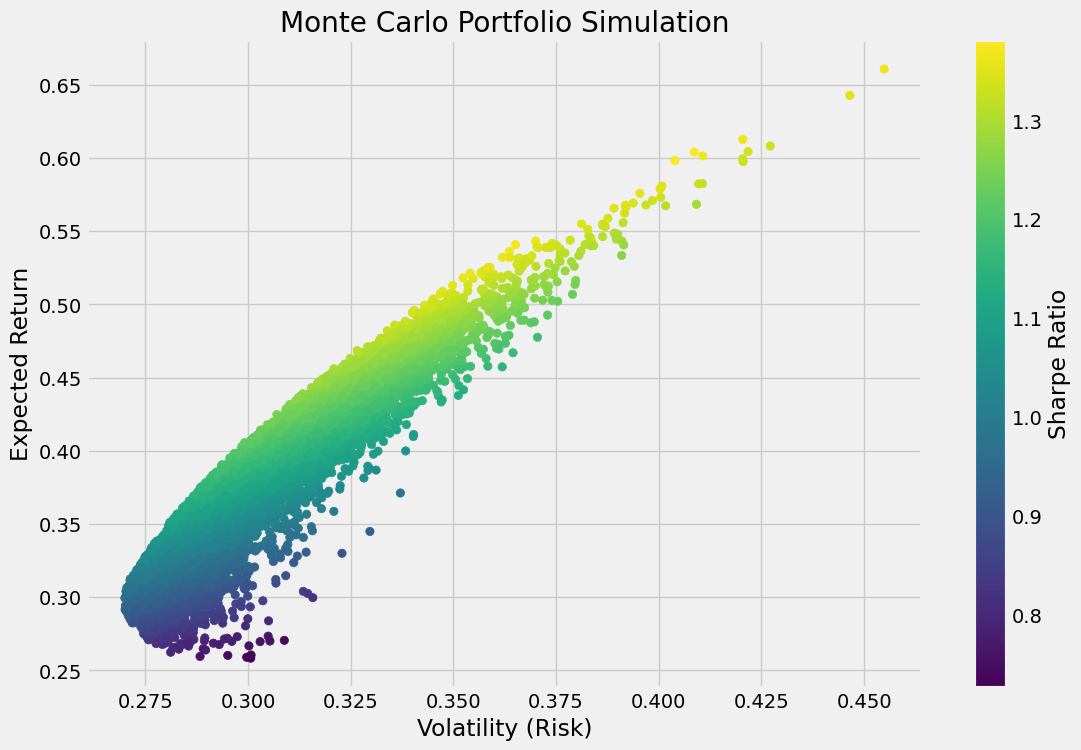

In [41]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    portfolio_df['Volatility'],
    portfolio_df['Return'],
    c=portfolio_df['Sharpe Ratio'],
    cmap='viridis'
)

plt.colorbar(scatter, label='Sharpe Ratio')

plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')

plt.title('Monte Carlo Portfolio Simulation')


plt.savefig('../images/monte_carlo_simulation.png',
            bbox_inches='tight')
plt.show()

Portfolio volatility depends on asset covariances. Since the assets are correlated, not every risk-return combination is achievable. The resulting feasible set forms a curved region rather than a rectangular space.

## Monte Carlo Portfolio Simulation

Each point represents a randomly generated portfolio allocation.

The horizontal axis represents annualized volatility (risk), while the vertical axis represents expected annual return.

Color indicates the Sharpe Ratio, a measure of risk-adjusted performance.

The collection of points forms the feasible portfolio set, representing all attainable risk-return combinations generated from the selected assets.

## Finding the best Portfolio

In [24]:
max_sharpe_idx = portfolio_df['Sharpe Ratio'].idxmax()

max_sharpe_portfolio = portfolio_df.loc[max_sharpe_idx]

max_sharpe_portfolio

Return          0.598136
Volatility      0.403949
Sharpe Ratio    1.381699
Name: 6001, dtype: float64

## Finding the Minimum-Risk Portfolio

In [25]:
min_vol_idx = portfolio_df['Volatility'].idxmin()

min_vol_portfolio = portfolio_df.loc[min_vol_idx]

min_vol_portfolio

Return          0.299412
Volatility      0.270002
Sharpe Ratio    0.960780
Name: 9142, dtype: float64

In [26]:
max_sharpe_weights = portfolio_weights[max_sharpe_idx]

max_sharpe_weights

array([0.29229358, 0.01986251, 0.04911849, 0.00950999, 0.62921542])

In [27]:
min_vol_weights = portfolio_weights[min_vol_idx]

min_vol_weights

array([0.2963765 , 0.11518244, 0.28023529, 0.30486967, 0.0033361 ])

In [29]:
pd.DataFrame({
    'Stock' : stocks,
    'Weight' : max_sharpe_weights
})

,Stock,Weight
0,AAPL,0.292294
1,MSFT,0.019863
2,NVDA,0.049118
3,AMZN,0.009510
4,GOOGL,0.629215


In [31]:
pd.DataFrame({
    'Stocks' : stocks,
    'Weight' : min_vol_weights
})

,Stocks,Weight
0,AAPL,0.296376
1,MSFT,0.115182
2,NVDA,0.280235
3,AMZN,0.304870
4,GOOGL,0.003336


The maximum Sharpe portfolio concentrated primarily in GOOGL and AAPL because these stocks provided a strong balance between expected return and risk. Despite NVDA's superior return, its higher volatility reduced its attractiveness on a risk-adjusted basis.

Even though NVDA is volatile individually, its interaction with the other assets can still help reduce total portfolio risk.

One Limitation of the Current Method

We're using:

annual_returns = returns.mean() * 252

which uses historical average returns.

Because the simulation is based on random portfolios, the exact optimal weights can vary slightly each run.

A more rigorous optimization would use:

scipy.optimize.minimize()

to mathematically find the exact optimum.

## Visualizing the Portfolios

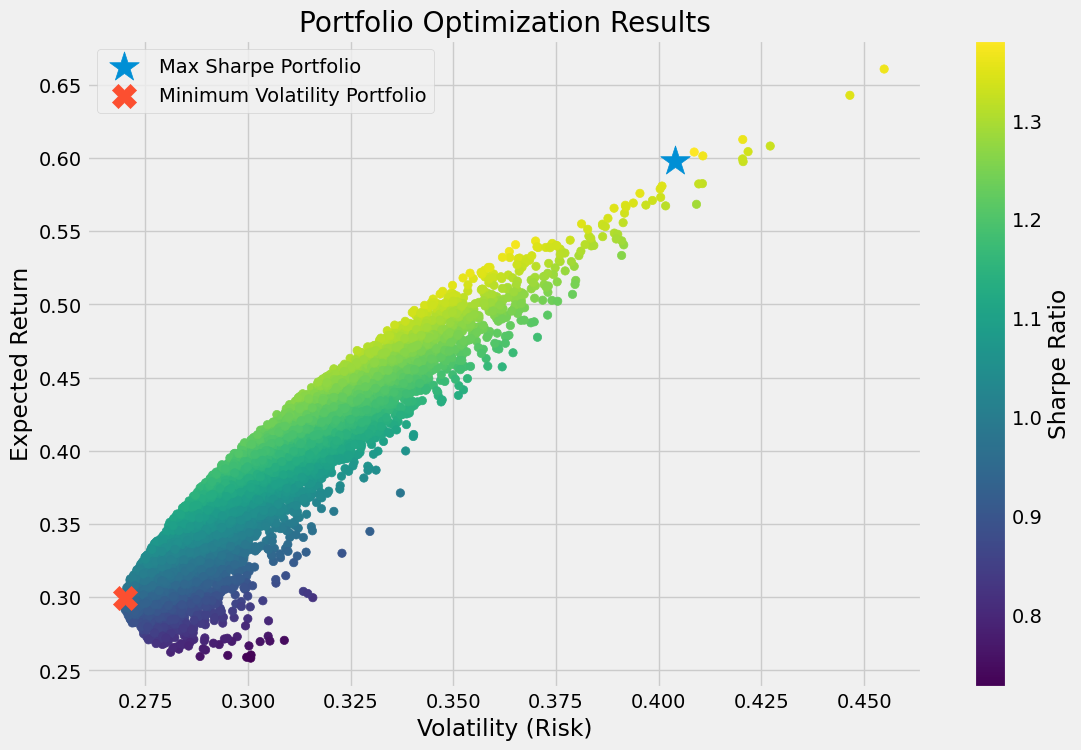

In [44]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    portfolio_df['Volatility'],
    portfolio_df['Return'],
    c=portfolio_df['Sharpe Ratio'],
    cmap='viridis'
)

plt.colorbar(scatter, label='Sharpe Ratio')

plt.scatter(
    max_sharpe_portfolio['Volatility'],
    max_sharpe_portfolio['Return'],
    marker='*',
    s=500,
    label='Max Sharpe Portfolio'
)

plt.scatter(
    min_vol_portfolio['Volatility'],
    min_vol_portfolio['Return'],
    marker='X',
    s=300,
    label='Minimum Volatility Portfolio'
)

plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.title('Portfolio Optimization Results')

plt.legend()

plt.savefig('../images/portfolio_optimization_results.png', bbox_inches = 'tight')
plt.show()

## Approximate Efficient Frontier

The Efficient Frontier represents portfolios that provide the highest expected return for a given level of risk.

Using the Monte Carlo simulation results, an approximate frontier is obtained by selecting the highest-return portfolio within each volatility range.

In [34]:
bins = np.linspace(
    portfolio_df['Volatility'].min(),
    portfolio_df['Volatility'].max(),
    50
)

In [35]:
frontier_returns = []
frontier_volatility = []

for i in range(len(bins)-1):

    temp = portfolio_df[
        (portfolio_df['Volatility'] >= bins[i]) &
        (portfolio_df['Volatility'] < bins[i+1])
    ]

    if len(temp) > 0:

        best_portfolio = temp.loc[temp['Return'].idxmax()]

        frontier_returns.append(best_portfolio['Return'])

        frontier_volatility.append(best_portfolio['Volatility'])

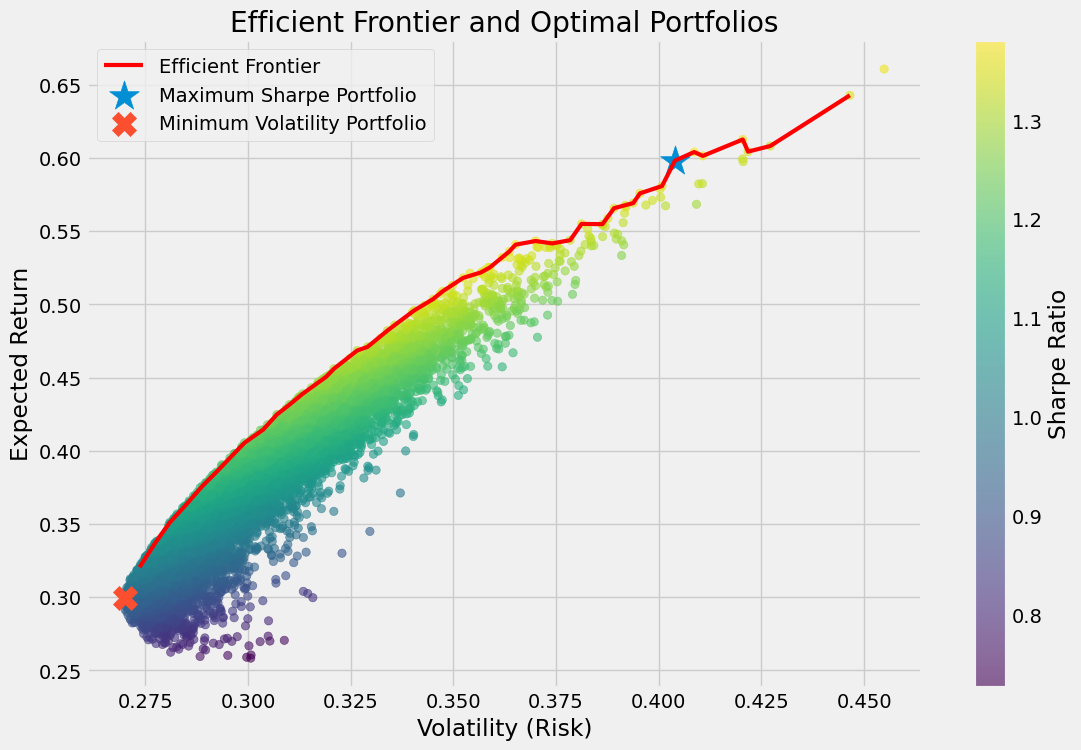

In [42]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    portfolio_df['Volatility'],
    portfolio_df['Return'],
    c=portfolio_df['Sharpe Ratio'],
    cmap='viridis',
    alpha=0.6
)

plt.colorbar(scatter, label='Sharpe Ratio')

plt.plot(
    frontier_volatility,
    frontier_returns,
    color='red',
    linewidth=3,
    label='Efficient Frontier'
)

plt.scatter(
    max_sharpe_portfolio['Volatility'],
    max_sharpe_portfolio['Return'],
    marker='*',
    s=500,
    label='Maximum Sharpe Portfolio'
)

plt.scatter(
    min_vol_portfolio['Volatility'],
    min_vol_portfolio['Return'],
    marker='X',
    s=300,
    label='Minimum Volatility Portfolio'
)

plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier and Optimal Portfolios')

plt.legend()

plt.savefig('../images/efficient_frontier.png',
            bbox_inches='tight')

plt.show()

In [38]:
max_sharpe_table = pd.DataFrame({
    'Stock': stocks,
    'Weight (%)': max_sharpe_weights * 100
})

max_sharpe_table

,Stock,Weight (%)
0,AAPL,29.229358
1,MSFT,1.986251
2,NVDA,4.911849
3,AMZN,0.950999
4,GOOGL,62.921542


In [39]:
min_vol_table = pd.DataFrame({
    'Stock': stocks,
    'Weight (%)': min_vol_weights * 100
})

min_vol_table

,Stock,Weight (%)
0,AAPL,29.637650
1,MSFT,11.518244
2,NVDA,28.023529
3,AMZN,30.486967
4,GOOGL,0.333610


In [40]:
max_sharpe_table['Weight (%)'] = max_sharpe_table['Weight (%)'].round(2)

min_vol_table['Weight (%)'] = min_vol_table['Weight (%)'].round(2)